In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
from cmath import inf,pi,exp
import IPython,ipywidgets as widgets
rad=(-1)**(1/cmath.pi)
deg=(-1)**(1/180)
inf=oo=cmath.inf
nan=cmath.nan
copysign=math.copysign

In [2]:
def Segments2Complex(Segs,p0=0.+0.j,scale=1.0,a0=0+1j,tol=0.002,offs=0,loops=1,return_start=False):
  """
  The parameter "tol defines the resolution. It is the maximum allowable
  difference between circular arc segment, and the secant between the
  calculated points on the arc. Smaller values for tol will result in
  more points per segment.
  """
  a=a0/abs(a0)
  p=p0*scale
  p-=1j*a*offs
  L=0
  if return_start:
      yield p,a,L,-1 #assuming closed loop: start-point = end-point
  loopcount=0
  while (loops==None) or (loops==inf) or (loopcount<loops):
      loopcount+=1
      for X,(l,da,*_) in enumerate(Segs):
        #if l<0:breakpoint()
        if l<0:#if the length is negative: add a full turn with the same curvature
            da_=copysign(2*pi,da)-da
            l=-l/da*da_
            da=da_
        l=l*scale
        if da!=0:
          r=l/da
          r+=offs
          if r!=0:
            l=r*da
            dl=2*abs(2*r*tol)**0.5
            n=max(int(abs(6*(da/(2*pi)))),int(l//dl)+1)
          else:
            n=1
          dda=exp(1j*da/n)
          dda2=dda**0.5
          v=(2*r*dda2.imag)*dda2*a
        else:
          n=1
          dda=1
          v=l*a
        for i in range(n):
          L+=l/n
          p+=v
          v*=dda
          a*=dda
          yield p,a,L,X

In [3]:
#Möbius transformation function definitions
matmul=lambda a,b,c,d, e,f,g,h:(a*e + b*g, a*f + b*h, c*e + d*g, c*f + d*h)# 2x2 Matrix multiplication
mt = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(a*x+b)/(c*x+d) if (c*x+d)!=0.0j else inf #mobius transformation
mti = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(-d*x+b)/(c*x-a) if (c*x-a)!=0.0j else inf # inverse mobius transformation
dmt_dx = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(a*d-b*c)/(c*x+d)**2 if (c*x+d)!=0.0j else inf #1st derivative of mobius transformation (rot&scale)
dmti_dx = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :(a*d-b*c)/(c*x-a)**2 if (c*x-a)!=0.0j else inf#1st derivative of inverse mobius transformation (rot&scale)
d2mt_dx2 = lambda x,a=1.0,b=0.0,c=0.0,d=1.0 :-2*c*(a*d-b*c)/(c*x+d)**3 #2nd derivative of mobius transformation (curvature)

In [4]:
def arc_from_chord(p1,t1,p2,eps=1e-6):
    if p2==inf:
        return inf,0 # straight ray towards infinity
    ch1=p2-p1#chord
    ph1=ch1/t1 
    ph1/=abs(ph1)
    sinph1=ph1.imag
    ang1=cmath.polar(ph1)[1] #angle between arc and chord ]-pi...pi] 
    if (pi-abs(ang1))<eps: #straidgt line away from p2 -> arc close to pole
        return -abs(ch1),0.0 #negative length means: two rays in opposite directions, with a gap between p1 and p2
    l1=abs(ch1)*(1 if sinph1==0 else ang1/sinph1) #convert 
    return l1,2*ang1
    
def compute_biarc(p1,t1,p2,t2,p=None,P=None):
    m=(2,-(p1+p2),0,p2-p1) # rotate&scale p1->-1, p2->+1
    
    phl=(t2*t1.conjugate())**0.5 
    phl/=abs(phl) 
    ml=(phl+1,phl-1,phl-1,phl+1)# junction locus circle->real axis
    mn=matmul(*ml,*m) #normalization matrix junction points on real axis
    
    phj=t1*dmt_dx(p1,*mn) #angle at junction circle with respect to junction circle
    
    if P==None:
        if p==None:
            p=1.0
    else:
        pn=mt(P,*mn)
        if pn.imag>0:# point is on arc2
            w=(pn+1)/(-pn+1)
            p=w.real+w.imag/phj.imag*phj.real
        else: #point is on arc1
            w=(pn-1)/(pn+1)
            p=-1/(w.real+w.imag/phj.imag*phj.real)
                
    xj=(p-1)/(p+1)
    pj=mti(xj,*mn)#convert normalized coordinates to world coordinates
    tj=phj.conjugate()*dmti_dx(xj,*mn)#rotation between normalized and world coordinate system
    tj/=abs(tj)
   
    tl=dmti_dx(-1,*mn)#tangent vector of junction locus circle at p1
    tl/=abs(tl)
    
    return pj,tj,tl,p
    

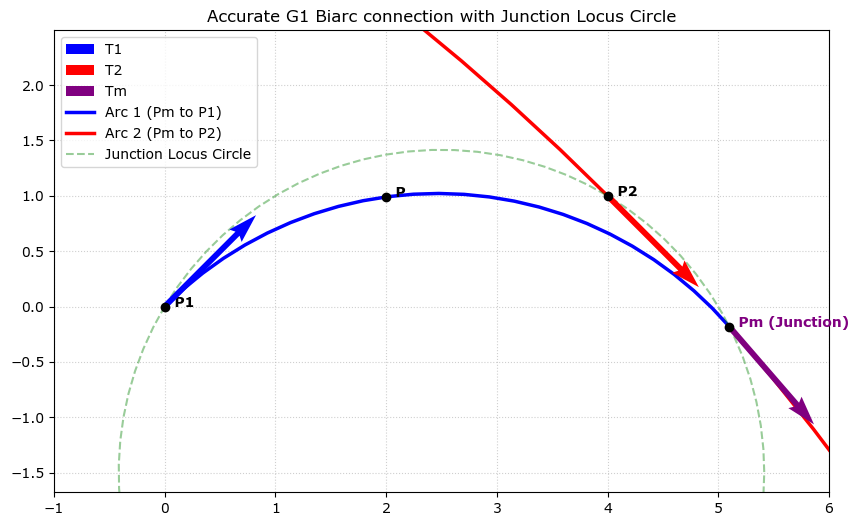

In [5]:
def plot_arc(p1,t1,p2,*args,**kwargs):
    if p1==inf:
        p1,t1,p2=p2,-t1,p1 #draw arc backwards
    l,ang=arc_from_chord(p1,t1,p2)
    if l==inf :
        l=1000
    if ang==0 and l<0: #straight infinite line with a gap: plot two lines, one in the opposite direction, starting at p2
        l=1000
        plt.plot(*zip(*([p.real,p.imag] for p,*_ in Segments2Complex([[l,ang]], p0=p2, a0=-t1,scale=1.0,return_start=True))),
             *args,**kwargs)
    plt.plot(*zip(*([p.real,p.imag] for p,*_ in Segments2Complex([[l,ang]], p0=p1, a0=t1,scale=1.0,return_start=True))),
             *args,**kwargs)

# --- Run & Plot ---
def plot_biarc(A,At,B,Bt,P,m=(1.0, 0.0, 0.0, 1.0),rmax=100,xlim=(-1.5,1.5),r_clip=1000):
    #A,B= (mt(x,*m) for x in (A,B))ü
    #At,Bt = (x*dmt_dx(x,*m) for x in (At,Bt))
    #p1, pm, p2, c1, r1, c2, r2, t1, t2, tm = compute_biarc_original_hybrid(A,At,B,Bt)
    p1,t1,p2,t2=A,At,B,Bt
    pm,tm,tl,p=compute_biarc(p1=A,t1=At,p2=B,t2=Bt,P=P)
    l1,ang1=arc_from_chord(p1,t1,pm)
    l2,ang2=arc_from_chord(pm,tm,p2)
    ll,angl=arc_from_chord(p1,tl,p2)
    
    t1,tm,t2,tl=(dmt_dx(p,*m)*t for p,t in ((p1,t1),(pm,tm),(p2,t2),(p1,tl)))
    p1,pm,p2,P=(mt(p,*m) for p in (p1,pm,p2,P))
    
    # Plotting
    plt.close()
    fig1=plt.figure(figsize=(10, 6))
 
    plt.scatter(*zip(*((x.real,x.imag) for x in [pm, P])), color='black', zorder=5)
    if abs(p1)<rmax: plt.scatter(p1.real, p1.imag, color='black', zorder=5)
    if abs(p2)<rmax: plt.scatter(p2.real, p2.imag, color='black', zorder=5)
    if abs(p1)<rmax: plt.text(p1.real, p1.imag, '  P1', fontdict={'weight': 'bold'})
    plt.text(pm.real, pm.imag, '  Pm (Junction)', fontdict={'weight': 'bold', 'color': 'purple'})
    if abs(p2)<rmax: plt.text(p2.real, p2.imag, '  P2', fontdict={'weight': 'bold'})
    plt.text(P.real, P.imag, '  P', fontdict={'weight': 'bold'})
    

    # Render tangent vectors
    if abs(p1)<rmax: plt.quiver(p1.real,p1.imag, t1.real, t1.imag, color='blue', scale=6, zorder=4, label='T1')
    if abs(p2)<rmax: plt.quiver(p2.real,p2.imag, t2.real, t2.imag, color='red', scale=6, zorder=4, label='T2')
    plt.quiver(pm.real,pm.imag, tm.real, tm.imag, color='purple', scale=6, zorder=4, label='Tm')
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.6)
    xl=plt.xlim()
    yl=plt.ylim() 
    
    plot_arc(pm,-tm,p1, 'b-', linewidth=2.5, label='Arc 1 (Pm to P1)')
    plot_arc(pm,tm,p2, 'r-', linewidth=2.5, label='Arc 2 (Pm to P2)')
    plot_arc(p1,tl, p2, 'g--', alpha=0.4, label='Junction Locus Circle')
    plot_arc(p1,-tl, p2, 'g--', alpha=0.4)#finish the circle in the opposite direction
    
    plt.xlim(xlim)#use limits passed as argument to this function
    #plt.xlim(( max(xl[0],-5.0),min(xl[1],5.0)))
    plt.ylim((yl)) 
    plt.legend(loc='upper left')
    plt.title("Accurate G1 Biarc connection with Junction Locus Circle")
    plt.close()
    return fig1
IPython.display.display(plot_biarc(0.0,deg**45,4+1j,deg**-45,2.0+1j*0.99,xlim=(-1,6)))

In [6]:
from ipywidgets import HBox,VBox,FloatSlider

state=dict(Ax=0.0,Ay=0.0,At=45.0,Bx=4.0,By=1.0,Bt=-45.0,Px=1.0,Py=0.825,p=1.0)
state=dict(Ax=0.0,Ay=0.0,At=45.0,Bx=4.0,By=1.0,Bt=-45.0,Px=3.0,Py=1.5,p=1.0)

output1,output2,output3,output4,output5,output6=(widgets.Output() for _ in range(6))

def update_outputs():
        A=state['Ax']+1j*state['Ay']
        At=deg**state['At']
        B=state['Bx']+1j*state['By']
        Bt=deg**state['Bt']
        P=state['Px']+1j*state['Py']
        p=state['p']
        m=(2,-(A+B),0,B-A)
        v_gamma = (Bt*At.conjugate())**0.5
        v_gamma/=abs(v_gamma)
        # 2. Normalized to Rectified Parameter Space Matrix
        M_norm_to_rect = (v_gamma +1, v_gamma-1,  v_gamma-1,  v_gamma+1)
        mtot=matmul(*M_norm_to_rect,*m)
        phi=At*dmt_dx(A,*mtot)
        phi/=abs(phi)
        mnA0=matmul(1,1,-1,1,*mtot)
        mnB0=matmul(1,-1,1,1,*mtot)
        output1.clear_output(wait=True)
        with output1:
            IPython.display.display(plot_biarc(A,At,B,Bt,P,xlim=(-1,5)))
        output2.clear_output(wait=True)
        with output2:
            print(f"{A=:.3}, {At=:.3}, {B=:.3}, {Bt=:.3}, {P=:.3}, {p=:.3}")
            pj,tj,*_,p_=compute_biarc(p1=A,t1=At,p2=B,t2=Bt,P=P)
            Pn=mt(P,*mtot)
            print(f"{Pn=:.3}, {p_=:.3}, {pj=:.3}, {tj=:.3}")
        output3.clear_output(wait=True)
        with output3:
            IPython.display.display(plot_biarc(A,At,B,Bt,P,m))
        output4.clear_output(wait=True)
        with output4:
            #print(f"{mtot=}")
            IPython.display.display(plot_biarc(A,At,B,Bt,P,mtot))
            print(f'{phi=:.3}')
        output5.clear_output(wait=True)
        with output5:
            IPython.display.display(plot_biarc(A,At,B,Bt,P,mnA0,xlim=(-0.5,4.5)))
            PnA=mt(P,*mnA0)
            p_A=PnA.real+PnA.imag/phi.imag*phi.real
            print(f"{mt(P,*mnA0)=:.3}, {p_A=:.3} ")
        output6.clear_output(wait=True)
        #breakpoint()
        with output6:
            IPython.display.display(plot_biarc(A,At,B,Bt,P,mnB0,xlim=(-4.5,0.5)))
            PnB=mt(P,*mnB0)
            p_B=-1/(PnB.real+PnB.imag/phi.imag*phi.real)
            print(f"{mt(P,*mnB0)=:.3}, {p_B=:.3}, {A=:.3}, {At=:.3}, {B=:.3}, {Bt=:.3}  ")
update_outputs()
def ChangeHandler(change):
    #with output2:
    #    print(change)
    if change['type']=='change' and change['name']=='value':
        state[change['owner'].description]=change['new']
        update_outputs()
        
Ax=FloatSlider(value=state['Ax'],min=-5,max=5, description='Ax');Ax.observe(ChangeHandler)
Ay=FloatSlider(value=state['Ay'], min=-5,max=5, description='Ay',orientation='vertical');Ay.observe(ChangeHandler)
At=FloatSlider(value=state['At'],min=-180,max=180 , description='At');At.observe(ChangeHandler)
Px=FloatSlider(value=state['Px'],min=-5,max=5, step=0 , description='Px');Px.observe(ChangeHandler)
Py=FloatSlider(value=state['Py'],min=-5,max=5, step=0, description='Py',orientation='vertical');Py.observe(ChangeHandler)
Bx=FloatSlider(value=state['Bx'],min=-5,max=5, description='Bx');Bx.observe(ChangeHandler)
By=FloatSlider(value=state['By'], min=-5,max=5, description='By',orientation='vertical');By.observe(ChangeHandler)
Bt=FloatSlider(value=state['Bt'], min=-180,max=180 , description='Bt');Bt.observe(ChangeHandler)
p=FloatSlider(value=state['p'],min=-5,max=5, step=0 , description='p');p.observe(ChangeHandler)
VBox([HBox( [output1,HBox([Ay,By,Py])]),HBox([VBox([Ax,At]),VBox([Px,p]),VBox([Bx,Bt])]),output2]) 

In [7]:
VBox([HBox([ output3,output4]), HBox([output5,output6])])